# Assignment 6: Clustering and Topic Modeling

In this assignment, we are going to look into clustering and similar techniques to get an overview of the types and topics of documents in our collection. Specifically, we will apply topic modeling with [Latent Dirichlet Allocation (LDA)](https://en.wikipedia.org/wiki/Latent_Dirichlet_allocation) and use the results to extract and visualize clusters of related documents.
Note: we use again the 'pandemic' dataset here.

## Code from previous assignments

First, we run some code copied from the previous assignments:

In [105]:
import pickle, bz2
from collections import defaultdict, namedtuple, Counter
from math import log10, sqrt
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# show plots inline within the notebook
%matplotlib inline
# set plots' resolution
plt.rcParams['savefig.dpi'] = 100

In [106]:

Summaries_file = 'data/pandemic_Summaries.pkl.bz2'
Abstracts_file = 'data/pandemic_Abstracts.pkl.bz2'


Summaries = pickle.load( bz2.BZ2File( Summaries_file, 'rb' ) )
Abstracts = pickle.load( bz2.BZ2File( Abstracts_file, 'rb' ) )

paper = namedtuple( 'paper', ['title', 'authors', 'year', 'doi'] )

for (id, paper_info) in Summaries.items():
    Summaries[id] = paper( *paper_info )

In [107]:
def display_summary( id, show_abstract=False, show_id=True, extra_text='' ):
    """
    Function for printing a paper's summary through IPython's Rich Display System.
    Trims long author lists, and adds a link to the paper's DOI (when available).
    """
    s = Summaries[id]
    lines = []
    title = s.title
    if s.doi != '':
        title = '<a href=http://dx.doi.org/{:s}>{:s}</a>'.format(s.doi, title)
    title = '<strong>' + title + '</strong>'
    lines.append(title)
    authors = ', '.join( s.authors[:20] ) + ('' if len(s.authors) <= 20 else ', ...')
    lines.append(str(s.year) + '. ' + authors)
    if (show_abstract):
        lines.append('<small><strong>Abstract:</strong> <em>{:s}</em></small>'.format(Abstracts[id]))
    if (show_id):
        lines.append('[ID: {:d}]'.format(id))
    if (extra_text != ''):
         lines.append(extra_text)
    display( HTML('<br>'.join(lines)) )

We will use a slightly modified tokenization function, which ignores all special characters:

In [108]:
chars = set('abcdefghijklmnopqrstuvwxyz ABCDEFGHIJKLMNOPQRSTUVWXYZ')

def tokenize(text):
    return ''.join(filter(chars.__contains__, text)).split(' ')

def preprocess(tokens):
    result = []
    for token in tokens:
        result.append(token.lower())
    return result

And then we create our inverted index as before:

In [109]:
inverted_index = defaultdict(list)

for id in sorted(Summaries.keys()):
    term_set = set(preprocess(tokenize(Summaries[id].title)))
    if id in Abstracts:
        term_set.update(preprocess(tokenize(Abstracts[id])))
    for term in term_set:
        inverted_index[term].append(id)

## Data preparation

To perform topic modeling on our data, we need a matrix representation, and as a first step we have to put our documents into a fixed sequence. We create a list for that, and for simplicity only include papers that have an abstract:

In [110]:
doc_list = [id for (id, abstract) in Abstracts.items()]

print(len(doc_list))

76118


Next, we need to do the same for the terms. To ensure that the matrix doesn't get too large, we will restrict ourselves here to the terms that appear in at least 100 documents, but in not more than 3% of all the documents. This gives us 4705 terms to work with:

In [111]:
short_term_list = [
    t for t in list(inverted_index.keys())
    if (len(inverted_index[t]) >= 100 and len(inverted_index[t]) < 0.03*len(doc_list))
]

print(len(short_term_list))
#print(short_term_list)

4705


Now that we have defined a fixed sequence for documents as well as terms, we can use this to create a term-document incidence matrix of boolean values denoting whether a given term appears in a given document. This requires the [NumPy](http://www.numpy.org/) package:

In [112]:
! pip install --user numpy


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [113]:
import numpy as np

doc_term_matrix = np.zeros((len(doc_list), len(short_term_list)), np.bool_)

# Make a temporary dictionary object for fast lookup:
short_term_map = {}
for i in range(len(short_term_list)):
    short_term_map[short_term_list[i]] = i

for d in range(0,len(doc_list)):
    for token in preprocess(tokenize(Abstracts[doc_list[d]])):
        if (token in short_term_map):
            doc_term_matrix[d,short_term_map[token]] = True

To find out, for example, whether the word "antibodies" is contained in the article with identifier 32909004, we first have to look up their position in our lists `short_term_list` and `doc_list`, respectively (the code below is not very efficient, but this is not our concern here):

In [114]:
print(short_term_list[3])
termid = short_term_list.index('antibodies')
print(termid)

docid = doc_list.index(32909004)
print(docid)

upon
27
16979


Knowing these positions, we can look up the value in our matrix, to find out that the given word is indeed mentioned in the given paper:

In [115]:
doc_term_matrix[docid,termid]

np.True_

Now we are ready to use this matrix to calculate topic for our documents.

## Topic Modeling

We are going to use the [lda](https://pypi.python.org/pypi/lda) package for this assignment, which you might have to download and install first.

In [116]:
!pip install --user lda


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [117]:
import lda

First, we have to specify how many topics we want to get and how many iterations the algorithm is supposed to run (the more iterations the more precise the result). We will first have a look at the result for 10 topics, and we store this configuration in a variable called `model10`. 100 iterations is a good value for our purposes here. Furthermore, we specify `random_state=1`, which will ensure that we will get exactly the same result when running the same code several times:

In [118]:
model10 = lda.LDA(n_topics=10, n_iter=100, random_state=1)

Next, we can give it our matrix to calcuate the topics and how they connect to our documents. This might take some time to compute (between 2 and 10 minutes):

In [119]:
model10.fit(doc_term_matrix);

INFO:lda:n_documents: 76118
INFO:lda:vocab_size: 4705
INFO:lda:n_words: 2013975
INFO:lda:n_topics: 10
INFO:lda:n_iter: 100
INFO:lda:<0> log likelihood: -22296603
INFO:lda:<10> log likelihood: -18452264
INFO:lda:<20> log likelihood: -17498286
INFO:lda:<30> log likelihood: -17254438
INFO:lda:<40> log likelihood: -17147640
INFO:lda:<50> log likelihood: -17086459
INFO:lda:<60> log likelihood: -17048084
INFO:lda:<70> log likelihood: -17026045
INFO:lda:<80> log likelihood: -17009452
INFO:lda:<90> log likelihood: -16997287
INFO:lda:<99> log likelihood: -16985673


The result can be found in `model10.topic_word_` and `model10.doc_topic_`, which show the connections of topics to the words and documents, respectively.

The following function prints out the 8 most important words per topic:

In [120]:
def show_topics(m):
    for i, topic_dist in enumerate(m.topic_word_):
        topic_words = np.array(short_term_list)[np.argsort(topic_dist)][:-9:-1]
        print('Topic {}: {}'.format(i, ' '.join(topic_words)))

show_topics(model10)

Topic 0: virtual training digital communication delivery barriers remote programs
Topic 1: december outbreaks africa organization surveillance wuhan epidemiological confirmed
Topic 2: government situation supply must policies governments issues capacity
Topic 3: cancer intensive hospitals surgery surgical department unit procedures
Topic 4: depression questionnaire perceived distress emotional behaviors family completed
Topic 5: variants cells antiviral host antibodies cell spike strains
Topic 6: p regression ci respectively decreased incidence trends january
Topic 7: dynamics framework find policies proposed individual modeling behavior
Topic 8: diagnostic samples tests performance tool sensitivity chain reaction
Topic 9: complications chronic inflammatory diabetes lung failure pneumonia pulmonary


`doc_topic_` is a matrix where each row stands for one of our documents and each column represents one of the 10 topics. Let's have a look at the values for a particular document, say the one at position 80:

In [121]:
doc_topic10 = model10.doc_topic_
doc_topic10[80,:]

array([0.004, 0.004, 0.004, 0.004, 0.004, 0.604, 0.124, 0.004, 0.004,
       0.244])

You might be getting different values, as topic modeling is not deterministic, but all values are non-negative (typically larger than zero). Moreover, there is often one topic that has a clearly higher value than the others. We can find out about position of the highest value in the array with the function `np.argmax`:

In [122]:
np.argmax(doc_topic10[80,:], axis=0)

np.int64(5)

We can also verify that the sum of all the values corresponds to 1 (possibly with a bit of a rounding error):

In [123]:
sum(doc_topic10[80,:])

np.float64(1.0)

To get a feeling of the data, let's make a [scatter plot](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.scatter) of how the documents are distributed with respect to topics 0 and 1:

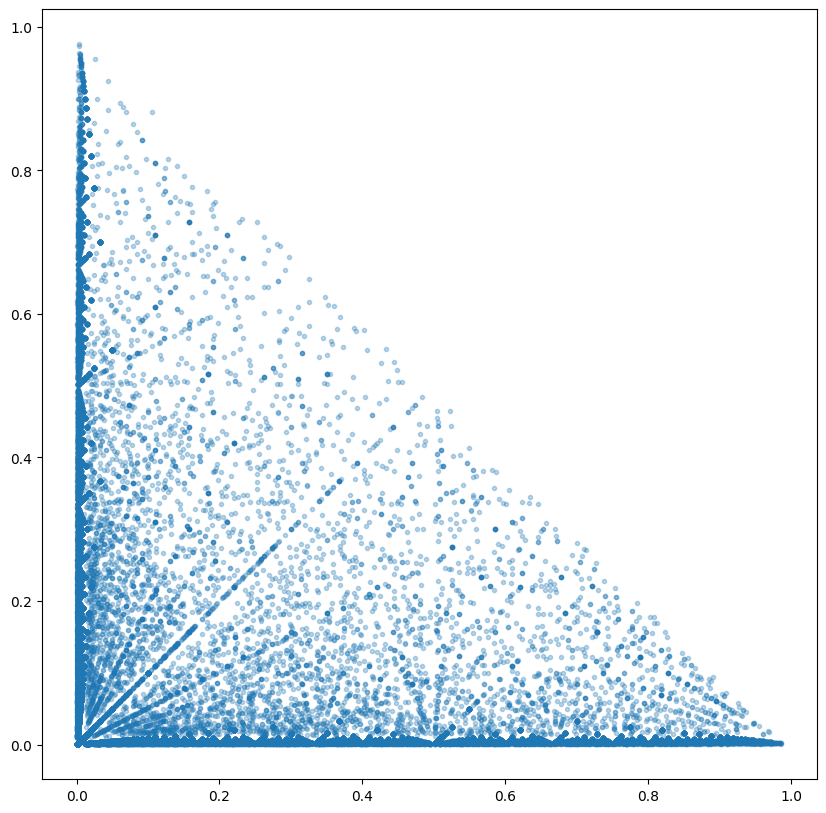

In [124]:
# Make the plots a bit larger:
plt.rcParams["figure.figsize"] = [10, 10]

plt.scatter(doc_topic10[:,0], doc_topic10[:,1], marker='.', alpha=0.3);

We see that most documents are close to the zero value for topic 0 or topic 1 or both. This is not surprising, because we have 10 topics but are only showing two of them. Most documents have their highest values on one of the other eight topics, and therefore show up at the edges of this plot.

We also see a triangle shaped distribution. This is also not surprising: for any given document, all values add up to 1, and therefore no document can have a value of more than 0.5 for more than one topic at the same time. If we know the values for 9 out of the 10 topics, we can in fact calculate the value for the tenth topic too. In other words, the last topic column doesn't contain extra information.

For nicer visualization, we can use the `color` argument to specify a color. We can give it also a list of values to declare different colors for the different data points. Here we just draw the first half of the points red, and the second half green:

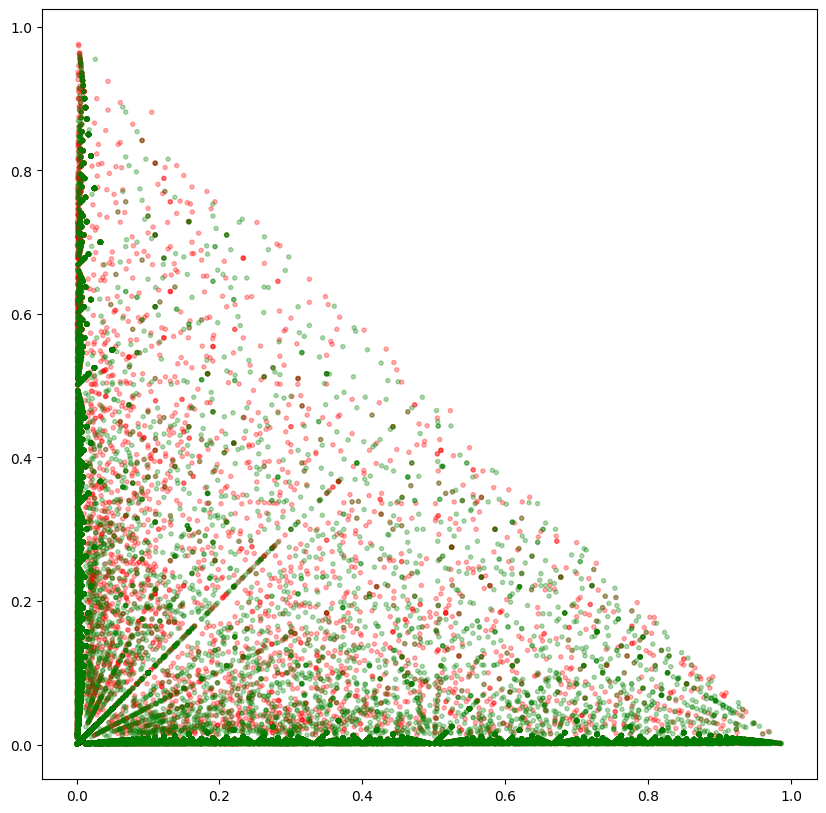

In [125]:
s = len(doc_topic10[:,0])
red_n = int(s/2)
green_n = s - red_n
color_list = ['r'] * red_n + ['g'] * green_n

plt.scatter(doc_topic10[:,0], doc_topic10[:,1], marker='.', alpha=0.3, color=color_list);

The above is a very random use of colors, because they don't map to anything sensible in our data, but we will have a more meaningful application below.

We can also call `plt.scatter` several times to overlay multiple plots. We can use that, for example, to highlight a selected paper, such as 32909004:

[0.00238095 0.16904762 0.00238095 0.00238095 0.00238095 0.19285714
 0.00238095 0.00238095 0.62142857 0.00238095]


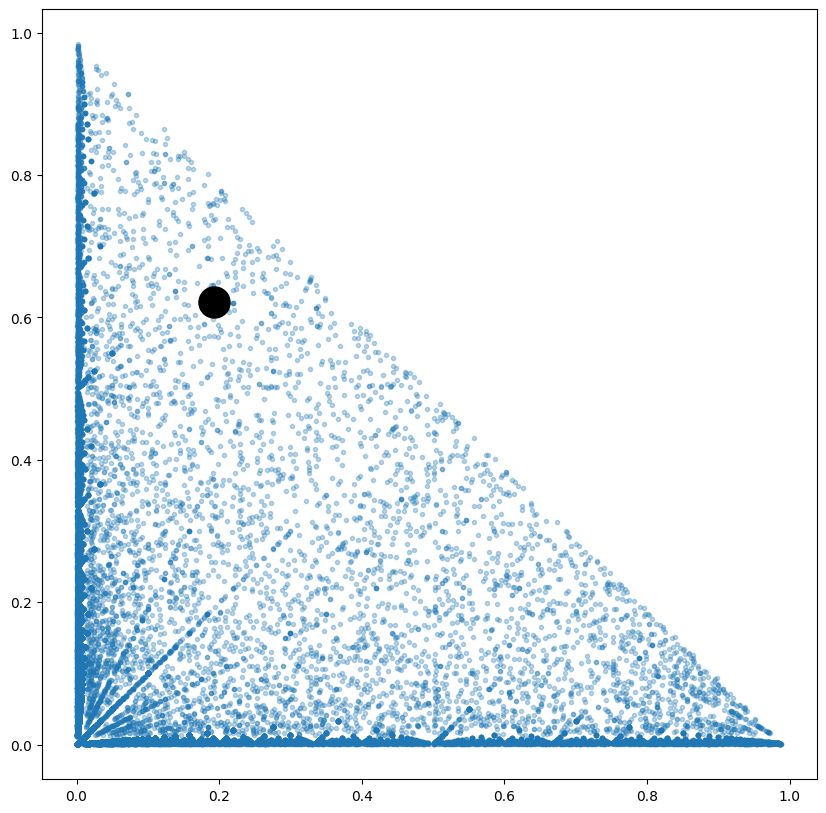

In [126]:
# Note that topic 5 and 8 are chosen in this demo because they have a good match,  
# and demonstrates well an interesting position in the plot
plt.scatter(doc_topic10[:,5], doc_topic10[:,8], marker='.', alpha=0.3)

i = doc_list.index(32909004)
print(doc_topic10[i,:])
plt.scatter(doc_topic10[i,5], doc_topic10[i,8], s=500, marker='o', color='k');

In [127]:
# Lets check if the content reflects topic 5 and topic 8
# Topic 5: variants antibodies strains antibody immunity spike humans emergence
# diagnostic tests equipment performance personal chain sensitivity standard

display_summary(32909004)

In the tasks below, you are now asked to build upon this and provide a better 2-dimensional visualization of the document topic space.

----------

# Tasks

**Your name:** Zayne Melendez

### Task 1

The problem with the above plots was that they only covered 2 out of 10 topics. To get a better 2-dimensional "landscape" of the topics in our documents, we want to calculate another topic model with just 3 instead of 10 topics. As we have seen above, the last topic doesn't add additional information, and therefore we can optimally plot 3 topics on a 2-dimensional space.

Initialize a new topic model configured to calculate 3 topics and save it in a variable called `model3` (use otherwise the same parameter values as above). Feed the same matrix as above as input to this model to calculate the topic mappings. Use then the `show_topics` function defined above to output a summary of the generated topics.

In [128]:
model3 = lda.LDA(n_topics=3, n_iter=100, random_state=1)
model3.fit(doc_term_matrix)
print(f"\nNew Topics:\n")
show_topics(model3)

INFO:lda:n_documents: 76118
INFO:lda:vocab_size: 4705
INFO:lda:n_words: 2013975
INFO:lda:n_topics: 3
INFO:lda:n_iter: 100
INFO:lda:<0> log likelihood: -18913261
INFO:lda:<10> log likelihood: -17295296
INFO:lda:<20> log likelihood: -16606691
INFO:lda:<30> log likelihood: -16524509
INFO:lda:<40> log likelihood: -16514618
INFO:lda:<50> log likelihood: -16518861
INFO:lda:<60> log likelihood: -16525986
INFO:lda:<70> log likelihood: -16529946
INFO:lda:<80> log likelihood: -16529563
INFO:lda:<90> log likelihood: -16531050
INFO:lda:<99> log likelihood: -16532102



New Topics:

Topic 0: training issues recommendations practices communication framework personal technology
Topic 1: depression regression p assessed older questionnaire incidence n
Topic 2: cells antiviral drugs variants cell host molecular drug


### Task 2

Now create a scatter plot of the form introduced above to visualize your new topic model created in Task 1. Explain what the three corners of the triangle in your plot stand for with respect to the three topics.

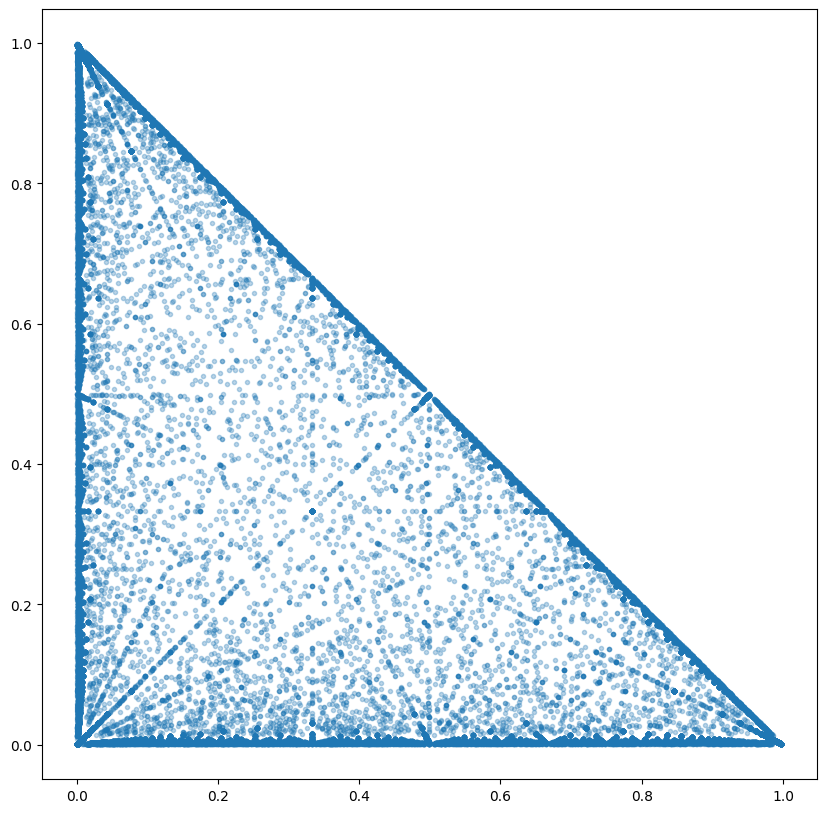

In [137]:
docTopic3 = model3.doc_topic_
plt.scatter(docTopic3[:,1], docTopic3[:,2], marker='.', alpha=0.3)


**Answer:** 

The three corners are the edge cases where the values for probability a document belongs under a cerain topic is either 1.0 (100%) or 0.0 (0%): 

In my graph's case:
* The top left corner represents cases where 100% falls under topic 2. (0% for everything else since it can add up to at most 100% which is already taken up on the y axis)
* The bottom left corner represents cases where 100% falls under topic 0 (graph shows 0% for both topic 1 and topic 2 and therefore must fall under the remaining topic 0)
* The bottom right corner represents cases where 100% falls under topic 1 (0% for everything else since it can add up to at most 100% which is already taken up on the x axis)

### Task 3

The results from tasks 1 and 2 give us a landscape to position papers in, but we would also like to use colors to indicate better what the different areas mean. For that, we go back to the topic model we defined first with 10 topics. We still have the result stored in the variables `model10` and `doc_topic10`. To understand these 10 topics a bit better, write a function `show_top_papers_on_topic` that takes a topic number from 0 to 9, and outputs the top 3 papers with the highest score on the given topic. Use `display_summary` to display the results and demonstrate your function by calling it to show the top 3 papers for topic 9.

Look at the top 3 papers for each topic and also consult the results for `show_topics(model10)` above to understand a bit better what these topics stand for. Based on this, create a list `topic_labels` with 10 string elements that give a short human-readable label for each of the 10 topics (for example 'side effects' or 'clinical studies').

In [130]:
def showTopHelper(topThreeDocs, docTopicCopy, topicNumber):
    topDocumentIndex = np.argmax(docTopicCopy[:,topicNumber], axis=0)
    topDocumentID = doc_list[topDocumentIndex]
    topThreeDocs.append(topDocumentID)
    docTopicCopy[topDocumentIndex, topicNumber] = -1

def show_top_papers_on_topic(topicNumber):
    if topicNumber < 0 or topicNumber >= model10.n_topics:
        print("Invalid topic number.")
        return
    else:
        topThreeDocs = []
        docTopicCopy = np.copy(doc_topic10)
        showTopHelper(topThreeDocs, docTopicCopy, topicNumber)
        showTopHelper(topThreeDocs, docTopicCopy, topicNumber)
        showTopHelper(topThreeDocs, docTopicCopy, topicNumber)
        print(f"Top 3 papers on topic {topicNumber}:\n")
        for docID in topThreeDocs:
            display_summary(docID, show_abstract=True)

topic_labels = [
    "Digital Healthcare and Telemedicine",
    "Disease outbreaks",
    "Ethics & Safety",
    "Treatments & Procedures",
    "Neurological Effects",
    "Cells and Antibodies",
    "Testing and Statistics",
    "Governance and Policy",
    "Diagnostic Testing Technologies",
    "Severe complications"
]

print("Topic list")
show_topics(model10)
print("")

print("Labels:")
for i in range(len(topic_labels)):
    print(f"Topic {i}: {topic_labels[i]}")
print("")

# Demonstrate with topic 9
show_top_papers_on_topic(9)


Topic list
Topic 0: virtual training digital communication delivery barriers remote programs
Topic 1: december outbreaks africa organization surveillance wuhan epidemiological confirmed
Topic 2: government situation supply must policies governments issues capacity
Topic 3: cancer intensive hospitals surgery surgical department unit procedures
Topic 4: depression questionnaire perceived distress emotional behaviors family completed
Topic 5: variants cells antiviral host antibodies cell spike strains
Topic 6: p regression ci respectively decreased incidence trends january
Topic 7: dynamics framework find policies proposed individual modeling behavior
Topic 8: diagnostic samples tests performance tool sensitivity chain reaction
Topic 9: complications chronic inflammatory diabetes lung failure pneumonia pulmonary

Labels:
Topic 0: Digital Healthcare and Telemedicine
Topic 1: Disease outbreaks
Topic 2: Ethics & Safety
Topic 3: Treatments & Procedures
Topic 4: Neurological Effects
Topic 5: C

### Task 4

Now we can combine our model with 3 topics with the one with 10 topics: We will use the 3-topic one to define the position of the documents in 2-dimensional space, as in tasks 1 and 2, and we will use the 10-topic one to define a color scheme and attach topic labels to these colors. So we end up with 2 dimensions and 10 colors.

For that, we first import some more packages and define ten colors (so we can access the colors with `colors[0]`, `colors[1]`, etc.). You don't need to change anything in this code block:

In [131]:
import matplotlib.patches as mpatches
import matplotlib.cm as cm

colors = cm.rainbow(np.linspace(0, 1, 10))

Now, create a list called `clusters` that has the same size and ordering as `doc_list` and specifies which cluster the given document belongs to. For that, we use our topic model with 10 topics (`model10`) in the following way: all documents that have their highest value for topic 0 belong to cluster 0; those with the highest value for topic 1 go to cluster 1; etc. (Hint: you can use the `np.argmax` function as shown above to find the position with the highest value in a list.)

Then copy the code for the scatter plot from task 2, but use the `c` argument to plot each document in the color corresponding to its cluster (hint: you can create a list of colors first, where the first element stands for the color of the first document, the second for the color of the second document, and so on). You can experiment with the values for `marker`, `alpha`, and `s` to improve the visual appearance.

In the end you can run the command below to add a legend to the plot, using the colors and labels as defined above.

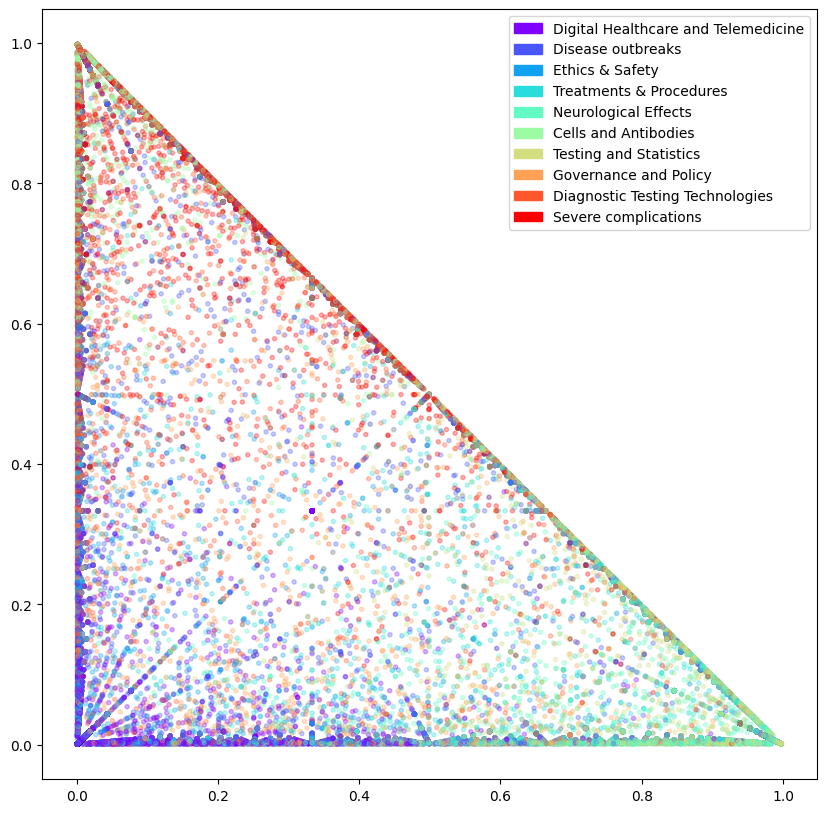

In [141]:
clusters = []
for i in range(len(doc_list)):
    topTopicIndex = np.argmax(doc_topic10[i,:], axis=0)
    clusters.append(topTopicIndex)
    
plt.scatter(docTopic3[:,1], docTopic3[:,2], marker='.', alpha=0.3, c = [colors[cl] for cl in clusters])

# Plot the legend:
plt.legend(handles=[mpatches.Patch(color=colors[i], label=topic_labels[i]) for i in range(0,10)]);

### Task 5

Finally, you should use the results from above to provide a function `show_paper` that takes a document identifier (like 32909004) and displays a summary of the paper (using `display_summary`) and shows its position in the "landscape" created above. For that, copy the code from Task 4 and additionally show a thick black dot to indicate the position of the given document in that landscape (see the code in the instructions above on how to show such a dot). Demonstrate your function by showing such a graphical summary for a paper where the black dot has an x an y position in your plot > 0.

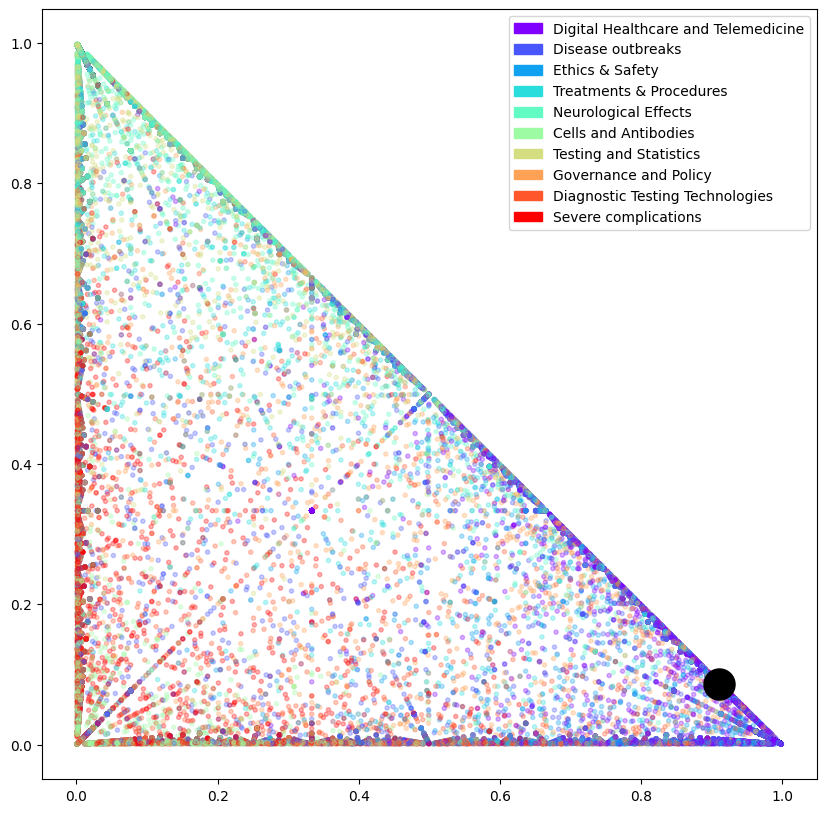

In [143]:
def show_paper(doc_id):
    n = doc_list.index(doc_id)
    display_summary(doc_id)
    plt.scatter(docTopic3[:,0], docTopic3[:,1], marker='.', alpha=0.3, c = [colors[cl] for cl in clusters])
    plt.scatter(docTopic3[n,0], docTopic3[n,1], s=500, marker='o', color='k')
    plt.legend(handles=[mpatches.Patch(color=colors[i], label=topic_labels[i]) for i in range(0,10)])

show_paper(32604587)

# Submission

Submit the answers to the assignment via Canvas as a modified version of this Notebook file (file with `.ipynb` extension) that includes your code and your answers.

Before submitting, restart the kernel and re-run the complete code (**Kernel > Restart & Run All**), and then check whether your assignment code still works as expected.

Don't forget to add your name, and remember that the assignments have to be done **individually**, and that code sharing or copying are **strictly forbidden** and will be punished.